cos:  1.0
q = 0.1962
D = 3153486080.315348
weak formulation done
maxh: 50
pad_radius: 10
min w [mm] = -4.174266264029425
Strech-faktor:  100


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

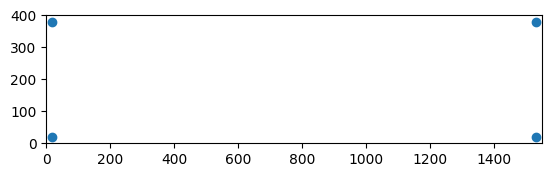

In [1]:
from ngsolve import *
from netgen.geom2d import SplineGeometry
import netgen.gui
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
from ngsolve import x,y
from netgen.occ import *
from math import pi, cos

"""
ReissnerMindlin nicht-TDNNS-Methode
die Punktauflager werden als Kreise mit Federkraft in Variationsformulierung miteinberechnet - schlecht!
"""


#PUNKT RAND/AUFLAGER
def ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,supports,factor=1,step=40,maxh=0.08,Neigungsfaktor_cos=1,pad_radius=35):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho*t*g * Neigungsfaktor_cos

    D = E*t**3/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G*t                     # Schubsteifigkeit
    A = E*t/(1-nu**2)              # Membransteifigkeit

    print("q =", q)
    print("D =", D)
    #endregion

    #region GEOMETRIE
    shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()

    shape.edges.name="free"

    rect = shape 
    
    geo = OCCGeometry(rect,dim=2)
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))

    mesh.Curve(3)
    # Draw(mesh)
    #endregion

    #region FEM-Räume
    order = 2
    Vw = H1(mesh, order=order)      # Durchbiegung
    Vb = VectorH1(mesh, order=order)    # Rotation

    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #Vw.FreeDofs()[vertex_num] = False
    #endregion
    
    # pad_radius = 35          # mm Lagerpad
    k_support = 5e4            # N'/mm³, vertikale Feder pro Fläche

    from ngsolve import x,y

    support_cf = 0
    for xs, ys in supports:
        r2 = (x-xs)*(x-xs) + (y-ys)*(y-ys)
        support_cf += IfPos(pad_radius*pad_radius-r2, 1, 0)

    #region FEM
    def eps_bending(b):
        return Sym(Grad(b))

    def inner_sym(A,B):
        return InnerProduct(A,B)

    a = BilinearForm(X, symmetric=True)
    # Biegung
    a += D * (
        (1-nu)*inner_sym(eps_bending(beta), eps_bending(eta))
        + nu*Trace(eps_bending(beta))*Trace(eps_bending(eta))
    ) * dx

    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    # Punkt-/Pad-Auflager
    a += k_support * support_cf * u*v * dx

    f = LinearForm(X)
    f += -q * v * dx

    a.Assemble()
    f.Assemble()
    print("weak formulation done")
    gf.vec.data = a.mat.Inverse(X.FreeDofs(), inverse="sparsecholesky") * f.vec


    print("maxh:",maxh)
    print("pad_radius:",pad_radius)
    print("min w [mm] =", min(w.vec.FV().NumPy()))

    #Draw(factor*w, mesh,deformation=True,euler_angles=[-60,5,30])

    print("Strech-faktor: ",factor)
    Draw(factor*w, mesh,deformation=True,euler_angles=[-60,5,30],settings={'Objects': {'Vectors': False, 'Wireframe': False, 'Surface': True}})
    Draw(factor*w,mesh,deformation=True,euler_angles=[-60,5,30],draw_surf=True, draw_vol=False)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)
    # print(x_points_ungerundet)
    # print(x_points)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #print(x_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{w:.2f}\n")

    import matplotlib.pyplot as plt

    xs = [x[0] for x in supports]
    ys = [x[1] for x in supports]
    plt.scatter(xs, ys)
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion
    return filename_GRAV

# KANTEN-RAND/AUFLAGER
def ReissnerMindlin_GRAV_Kante(Lx,Ly,t,supports,factor=1,step=40,maxh=0.08,Neigungsfaktor_cos=1):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho*t*g * Neigungsfaktor_cos

    D = E*t**3/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G*t                     # Schubsteifigkeit
    A = E*t/(1-nu**2)              # Membransteifigkeit

    print("q =", q)
    print("D =", D)
    #endregion

    #region GEOMETRIE
    shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()

    shape.edges.name="free" 
    shape.edges.Min(Y).name = "dirichlet"       # Platte steht auf dieser Kante

    rect = shape 
    
    geo = OCCGeometry(rect,dim=2)
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))

    mesh.Curve(3)
    # Draw(mesh)
    #endregion

    #region FEM-Räume
    order = 2
    Vw = H1(mesh, order=order,dirichlet="dirichlet")      # Durchbiegung
    Vb = VectorH1(mesh, order=order)    # Rotation

    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #endregion
    
    pad_radius = 0.001          # 35 mm Lagerpad
    k_support = 5e4            # N'/mm³, vertikale Feder pro Fläche

    from ngsolve import x,y

    support_cf = 0
    for xs, ys in supports:
        r2 = (x-xs)*(x-xs) + (y-ys)*(y-ys)
        support_cf += IfPos(pad_radius*pad_radius-r2, 1, 0)
    
    #region FEM
    def eps_bending(b):
        return Sym(Grad(b))

    def inner_sym(A,B):
        return InnerProduct(A,B)

    a = BilinearForm(X, symmetric=True)
    # Biegung
    a += D * (
        (1-nu)*inner_sym(eps_bending(beta), eps_bending(eta))
        + nu*Trace(eps_bending(beta))*Trace(eps_bending(eta))
    ) * dx

    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    # Punkt-/Pad-Auflager
    a += k_support * support_cf * u*v * dx

    f = LinearForm(X)
    f += -q * v * dx

    a.Assemble()
    f.Assemble()
    print("weak formulation done")
    gf.vec.data = a.mat.Inverse(X.FreeDofs(), inverse="sparsecholesky") * f.vec

    print("linear min w [mm] =", min(w.vec.FV().NumPy()))


    #Draw(factor*w, mesh,deformation=True,euler_angles=[-60,5,30],settings={'Objects': {'Vectors': True, 'Wireframe': False, 'Surface': False}})
    Draw(factor*w, mesh,deformation=True,euler_angles=[-60,5,30],draw_surf=False, draw_vol=False)
    print("Strech-faktor: ",factor)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)
    # print(x_points_ungerundet)
    # print(x_points)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #print(x_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{w:.2f}\n")

    # import matplotlib.pyplot as plt

    xs = [x[0] for x in supports]
    ys = [x[1] for x in supports]
    plt.scatter(xs, ys, color='blue', linewidth=3)
    plt.plot([0, Lx], [0, 0], color='blue', linewidth=3)

    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion
    return filename_GRAV


if __name__ =='__main__':
    Lx = 1550
    Ly = 400
    t  = 8               # Dicke
    step = 40           # Anzahl gespeicherter Punkte in x/y-Richtung im xyz-File

    # supports = [(0.4,0.1),(1.15,0.1),(0.4,0.3),(1.15,0.3)]
    # supports = [(0.875,0.1),(0.675,0.1),(0.875,0.3),(0.675,0.3)]
    factor = 100        # für den NGSolve-Plot
    maxh = 50           # die Dichtheit des Mesh
    pad_radius = 10

    Neigungswinkel_grad = 0 # Gradz
    Neigungswinkel_rad = Neigungswinkel_grad * pi/180
    Neigungsfaktor_cos = cos(Neigungswinkel_rad)
    print("cos: ",Neigungsfaktor_cos)

    #KANTEN-AUFLAGER
    # kanten_supports = [(2/10*Lx,Ly*8/10), (8/10*Lx,Ly*8/10)]
    # ReissnerMindlin_GRAV_Kante(Lx,Ly,t,kanten_supports,factor,step,maxh,Neigungsfaktor_cos)

    #PUNKT-AUFLAGER
    dosen_radius = 20 #mm
    supports = [(dosen_radius,dosen_radius), (dosen_radius,Ly-dosen_radius), (Lx-dosen_radius,dosen_radius), (Lx-dosen_radius,Ly-dosen_radius)] # supports1
    # supports = [(Lx/2 - dosen_radius,0),(Lx/2 - dosen_radius,Ly), (Lx/2 + dosen_radius,0),(Lx/2 + dosen_radius,Ly)] # supports2
    # supports = [(Lx/2 - 3*dosen_radius,0),(Lx/2 - 3*dosen_radius,Ly), (Lx/2 + 3*dosen_radius,0),(Lx/2 + 3*dosen_radius,Ly)]

    # supports = [(0,0),(0,Ly),(Lx,0),(Lx,Ly)]
    # supports = [(2/10*Lx,Ly*8/10), (8/10*Lx,Ly*8/10), (2/10*Lx,Ly*2/10),(8/10*Lx,Ly*2/10)]
    ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,supports,factor,step,maxh,Neigungsfaktor_cos,pad_radius)

